# 회귀분석
* 지도학습
* 종속변수(target) 변수가 수치형 자료
* 집값, 보험료, 몸무게와 같이 연속적인 숫자로 이루어진 값을 예측
* 회귀? => 평균으로 돌아감.

## 단순 선형 회귀분석 / 다중 선형 회귀분석
<br>

* 단순 선형 회귀분석: 독립변수 1개 - 종속변수 1개

* 다중 선형 회귀분석: 독립변수 여러개 - 종속변수 1개

1. 단순 회귀분석: 자동차 배기량과 연비 회귀분석

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import koreanize_matplotlib

In [4]:
#  X는 자동차 배기량, y는 연비
X = np.array([1,1.4,1.6,2,2.2,2.4,3,3.3,3.6])
y = np.array([15,13,13,12,11,10.5,10,9,8])

# 상수 추가 y절편 추가
X_with_const = sm.add_constant(X)

#모델 훈련
model=sm.OLS(y, X_with_const).fit()
y_pred=model.predict(X_with_const)

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.967
Model:                            OLS   Adj. R-squared:                  0.962
Method:                 Least Squares   F-statistic:                     203.7
Date:                Wed, 07 May 2025   Prob (F-statistic):           1.97e-06
Time:                        14:13:40   Log-Likelihood:                -3.9965
No. Observations:                   9   AIC:                             11.99
Df Residuals:                       7   BIC:                             12.39
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         16.8291      0.414     40.626      0.0

C:\Users\Admin\miniforge3\envs\fintech\lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=9
  res = hypotest_fun_out(*samples, **kwds)


* R-squared(정확도, 설명력): 해당 회귀분석 모델이 어느정도의 설명력을 가지고 있는가?
* Prob (F-statistic), P>|t| (P-value) : 0.05보다 작으면 귀무가설 기각. 상관관계 입증.
* coef : x가 1이 변할 때, y가 얼마나 변화하는지의 양
    * 배기량 1 증가 시, 연비 2.43 감소

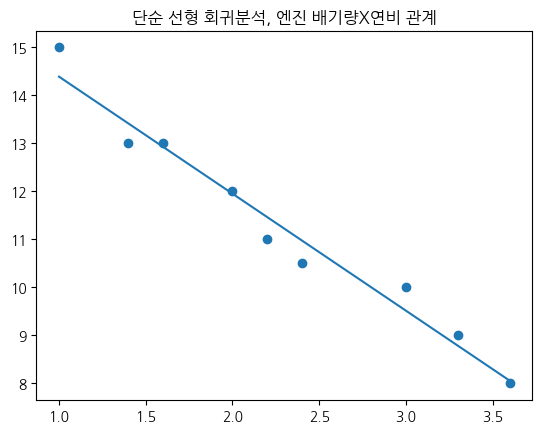

In [5]:
plt.scatter(X, y)
plt.plot(X,y_pred)
plt.title("단순 선형 회귀분석, 엔진 배기량X연비 관계")
plt.show()

* P값은 1.97e-06 이므로 0.001보다 작은 숫자로, 통계적으로 유의미.
* X1의 회귀계수는 -2.4371 
* y절편(상수항)은 16.8291
* 따라서 추정되는 회귀식은 y(연비) = -2.4371 * X1 + 16.8291

# 다중 회귀 분석
* 독립변수가 여러 개인 데이터 

In [6]:
# 데이터
yard = np.array([31,31,27,39,30,32,28,23,28,35])
area = np.array([58,51,47,35,48,42,43,56,41,41])
park = np.array([1,1,5,5,2,4,5,1,1,3])
dist = np.array([492,426,400,125,443,412,201,362,192,423])
price = np.array([12631,12084,12220,15649,11486,12276,15527,12666,13180,10169])

In [10]:
# 독립 변수와 종속 변수 설정
X = pd.DataFrame(dict(yard=yard, area=area, park=park, dist=dist))
y = price
print(X)
print(y)

   yard  area  park  dist
0    31    58     1   492
1    31    51     1   426
2    27    47     5   400
3    39    35     5   125
4    30    48     2   443
5    32    42     4   412
6    28    43     5   201
7    23    56     1   362
8    28    41     1   192
9    35    41     3   423
[12631 12084 12220 15649 11486 12276 15527 12666 13180 10169]


In [11]:
# 상수항 추가
X = sm.add_constant(X)
X

,const,yard,area,park,dist
0,1.0,31,58,1,492
1,1.0,31,51,1,426
2,1.0,27,47,5,400
3,1.0,39,35,5,125
4,1.0,30,48,2,443
5,1.0,32,42,4,412
6,1.0,28,43,5,201
7,1.0,23,56,1,362
8,1.0,28,41,1,192
9,1.0,35,41,3,423


In [12]:
# 훈련
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.918
Model:                            OLS   Adj. R-squared:                  0.853
Method:                 Least Squares   F-statistic:                     14.07
Date:                Wed, 07 May 2025   Prob (F-statistic):            0.00627
Time:                        14:39:40   Log-Likelihood:                -75.420
No. Observations:                  10   AIC:                             160.8
Df Residuals:                       5   BIC:                             162.4
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3045.6891   4084.218      0.746      0.4

C:\Users\Admin\miniforge3\envs\fintech\lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=10
  res = hypotest_fun_out(*samples, **kwds)


In [15]:
# 유효하지 않은 yard 값을 제외하고 다시 훈련 결과 도출
X2 = pd.DataFrame(dict(area=area, park=park, dist=dist))
X2 = X2[['area','park','dist']]
X2_const = sm.add_constant(X2)
X2_const

,const,park,dist
0,1.0,1,492
1,1.0,1,426
2,1.0,5,400
3,1.0,5,125
4,1.0,2,443
5,1.0,4,412
6,1.0,5,201
7,1.0,1,362
8,1.0,1,192
9,1.0,3,423


In [16]:
model2 = sm.OLS(y, X2_const).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.679
Model:                            OLS   Adj. R-squared:                  0.588
Method:                 Least Squares   F-statistic:                     7.416
Date:                Wed, 07 May 2025   Prob (F-statistic):             0.0187
Time:                        15:03:39   Log-Likelihood:                -82.263
No. Observations:                  10   AIC:                             170.5
Df Residuals:                       7   BIC:                             171.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.597e+04   1476.001     10.819      0.0

C:\Users\Admin\miniforge3\envs\fintech\lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=10
  res = hypotest_fun_out(*samples, **kwds)


### 다중회귀식
#### area와 dist만 사용한다는 가정
* y = (92.9476 * area) + (-14.4217 * dist) + 1.351e+04
* 모델 설명력은 Adj-R-squared = 0.680으로 봐야함.
* 모델의 p-value: 0.00766 이므로 통계적으로 유의미함

# 변수 선택
* 전진선택법 : 독립변수 0부터 변수를 1개씩 추가
* 후진제거법 : 모든 독립변수를 다 포함 => 변수를 1개씩 삭제
* 다중선택법 : 전진 + 후진
* AIC: 변수를 선택하는 지표

In [17]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression

In [19]:
# 데이터 생성
yard = np.array([31, 31, 27, 39, 30, 32, 28, 23, 28, 35])
area = np.array([58, 51, 47, 35, 48, 42, 43, 56, 41, 41])
park = np.array([1, 1, 5, 5, 2, 4, 5, 1, 1, 3])
dist = np.array([492, 426, 400, 125, 443, 412, 201, 362, 192, 423])
popul = np.array([4412, 2061, 4407, 1933, 4029, 4180, 3444, 1683, 3020, 4459])
price = np.array([12631, 12084, 12220, 15649, 11486, 12276, 15527, 12666, 13180, 10169])

# 데이터프레임 생성
data = pd.DataFrame({'yard': yard, 'area': area, 'park': park, 'dist': dist, 'popul': popul, 'price': price})

In [20]:
# 독립변수와 종속변수 설정
X = data.drop('price', axis=1)
y = data['price']

In [23]:
# 전진 선택법을 사용한 회귀분석
model = LinearRegression()
sfs = SequentialFeatureSelector(model, direction='forward')
sfs.fit(X,y)
# 선택된 변수
selected_features = X.columns[sfs.get_support()]
selected_features

Index(['yard', 'park'], dtype='object')

In [25]:
X.columns

Index(['yard', 'area', 'park', 'dist', 'popul'], dtype='object')

In [28]:
X_selected = sm.add_constant(data[selected_features])
X_selected 

,const,yard,park
0,1.0,31,1
1,1.0,31,1
2,1.0,27,5
3,1.0,39,5
4,1.0,30,2
5,1.0,32,4
6,1.0,28,5
7,1.0,23,1
8,1.0,28,1
9,1.0,35,3


In [30]:
final_model = sm.OLS(y, X_selected).fit()
print(final_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.194
Model:                            OLS   Adj. R-squared:                 -0.036
Method:                 Least Squares   F-statistic:                    0.8433
Date:                Wed, 07 May 2025   Prob (F-statistic):              0.470
Time:                        15:26:39   Log-Likelihood:                -86.871
No. Observations:                  10   AIC:                             179.7
Df Residuals:                       7   BIC:                             180.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        1.22e+04   3990.829      3.056      0.0

C:\Users\Admin\miniforge3\envs\fintech\lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=10
  res = hypotest_fun_out(*samples, **kwds)
